# 📊 SQL bilan Ma'lumotlar Tahlili Loyihasi
## Real E-commerce Dataset bilan EDA (Exploratory Data Analysis)

### 🎯 Loyiha maqsadi:
Ushbu loyihada biz real e-commerce ma'lumotlar to'plamini SQL orqali tahlil qilamiz va biznes uchun muhim xulosalar chiqaramiz.

### 📋 Loyiha bosqichlari:
1. **Ma'lumotlar bazasiga ulanish** va dataset ni o'rganish
2. **Ma'lumotlar sifatini baholash** va tozalash
3. **Tavsifiy statistika** va distribusiya tahlili
4. **Biznes savollariga javob topish** SQL orqali
5. **Mijozlar segmentatsiyasi** va xulosa

### 🛠️ Texnologiyalar:
- **SQLite** - ma'lumotlar bazasi
- **Python/Pandas** - ma'lumotlarni ko'rish
- **Matplotlib/Seaborn** - vizualizatsiya
- **SQL** - ma'lumotlar tahlili

---

**💡 Eslatma:** Ushbu loyiha real biznes stsenariylari asosida yaratilgan va SQL ko'nikmalaringizni amaliyotda qo'llash imkonini beradi!

## 1️⃣ Ma'lumotlar Bazasiga Ulanish va Sozlash

Birinchi navbatda kerakli kutubxonalarni import qilamiz va ma'lumotlar bazasiga ulanamiz.

In [1]:
# Kerakli kutubxonalarni import qilish
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Ma'lumotlar bazasiga ulanish
database_path = 'datasets/ecommerce_analysis.db'

try:
    # SQLAlchemy engine yaratish
    engine = create_engine(f'sqlite:///{database_path}')
    
    # Test ulanish
    test_query = "SELECT name FROM sqlite_master WHERE type='table';"
    tables = pd.read_sql(test_query, engine)
    
    print("✅ Ma'lumotlar bazasiga muvaffaqiyatli ulanildi!")
    print(f"📊 Mavjud jadvallar ({len(tables)} ta):")
    for table in tables['name']:
        print(f"   • {table}")
    
except Exception as e:
    print(f"❌ Ma'lumotlar bazasiga ulanishda xatolik: {e}")
    print("💡 Avval datasets/create_database.py faylini ishga tushiring!")

✅ Ma'lumotlar bazasiga muvaffaqiyatli ulanildi!
📊 Mavjud jadvallar (6 ta):
   • categories
   • sqlite_sequence
   • products
   • customers
   • orders
   • order_items


## 2️⃣ Dataset Import va Dastlabki O'rganish

Ma'lumotlar bazasidagi jadvallar tuzilishini o'rganamiz va asosiy ma'lumotlarni ko'rib chiqamiz.

In [11]:
# Har bir jadval haqida umumiy ma'lumot olish
def get_table_info(table_name):
    """Jadval haqida asosiy ma'lumotlarni qaytaradi"""
    try:
        # Yozuvlar soni
        count_query = f"SELECT COUNT(*) as count FROM {table_name};"
        count_result = pd.read_sql(count_query, engine)
        row_count = count_result['count'][0]
        
        # Jadval tuzilishi
        schema_query = f"PRAGMA table_info({table_name});"
        schema = pd.read_sql(schema_query, engine)
        
        # Birinchi 5 ta yozuv
        sample_query = f"SELECT * FROM {table_name} LIMIT 5;"
        sample_data = pd.read_sql(sample_query, engine)
        
        print(f"\n📊 {table_name.upper()} jadvali:")
        print(f"   Yozuvlar soni: {row_count:,}")
        print(f"   Ustunlar soni: {len(schema)}")
        print(f"   Ustunlar: {', '.join(schema['name'].tolist())}")
        print(f"\n📋 Jadval tuzilishi:")
        print(schema[['name', 'type', 'notnull']].to_string(index=False))
        print(f"\n🔍 Namuna ma'lumotlar:")
        print(sample_data.to_string(index=False))
        print("-" * 80)
        
        return {
            'table_name': table_name,
            'row_count': row_count,
            'columns': schema['name'].tolist(),
            'sample_data': sample_data
        }
        
    except Exception as e:
        print(f"❌ {table_name} jadvalini o'qishda xatolik: {e}")
        return None

# Barcha jadvallarni o'rganish
tables_info = {}
main_tables = ['categories', 'products', 'customers', 'orders', 'order_items']

print("🔍 Jadvallar tuzilishini o'rganish:")
print("=" * 80)

for table in main_tables:
    table_info = get_table_info(table)
    if table_info:
        tables_info[table] = table_info

🔍 Jadvallar tuzilishini o'rganish:

📊 CATEGORIES jadvali:
   Yozuvlar soni: 10
   Ustunlar soni: 4
   Ustunlar: category_id, category_name, description, created_at

📋 Jadval tuzilishi:
         name     type  notnull
  category_id  INTEGER        0
category_name     TEXT        1
  description     TEXT        0
   created_at DATETIME        0

🔍 Namuna ma'lumotlar:
 category_id     category_name                                    description          created_at
           1       Elektronika Telefonlar, kompyuterlar va boshqa elektronika 2025-09-23 11:04:43
           2 Kiyim va Poyafzal                  Erkaklar va ayollar kiyimlari 2025-09-23 11:04:43
           3        Uy va Bog'            Uy uchun buyumlar va bog' anjomlari 2025-09-23 11:04:43
           4          Kitoblar                   Badiiy va o'quv adabiyotlari 2025-09-23 11:04:43
           5  Sport va Faollik           Sport anjomlari va faollik buyumlari 2025-09-23 11:04:43
--------------------------------------------


📈 Ma'lumotlar bazasi umumiy ko'rinishi:
 table_name  row_count
 categories         10
   products        100
  customers       2000
     orders       8134
order_items      16315

📊 Jami yozuvlar: 26,559


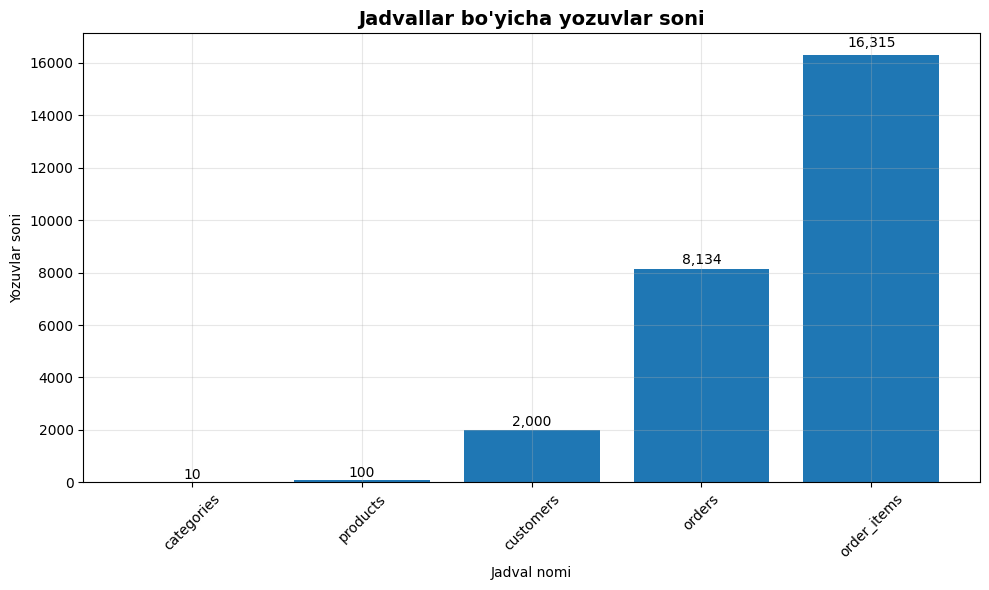

In [3]:
# Ma'lumotlar bazasi umumiy ko'rinishi
summary_query = """
SELECT 
    'categories' as table_name, COUNT(*) as row_count FROM categories
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL  
SELECT 'customers', COUNT(*) FROM customers
UNION ALL
SELECT 'orders', COUNT(*) FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items;
"""

db_summary = pd.read_sql(summary_query, engine)
print("\n📈 Ma'lumotlar bazasi umumiy ko'rinishi:")
print(db_summary.to_string(index=False))

# Jami ma'lumotlar
total_rows = db_summary['row_count'].sum()
print(f"\n📊 Jami yozuvlar: {total_rows:,}")

# Vizualizatsiya
plt.figure(figsize=(10, 6))
bars = plt.bar(db_summary['table_name'], db_summary['row_count'])
plt.title('Jadvallar bo\'yicha yozuvlar soni', fontsize=14, fontweight='bold')
plt.xlabel('Jadval nomi')
plt.ylabel('Yozuvlar soni')
plt.xticks(rotation=45)

# Raqamlarni ustiga qo'yish
for bar, count in zip(bars, db_summary['row_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + count*0.01, 
             f'{count:,}', ha='center', va='bottom')

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## 3️⃣ Ma'lumotlar Sifatini Baholash

Ma'lumotlardagi boʻsh qiymatlar, takrorlanuvchi ma'lumotlar va anomaliyalarni tekshiramiz.

In [4]:
# Ma'lumotlar sifatini tekshirish
print("🔍 Ma'lumotlar sifatini tekshirish:")
print("=" * 50)

# 1. NULL qiymatlarni tekshirish
def check_null_values():
    """Har bir jadvaldagi NULL qiymatlarni tekshiradi"""
    null_results = {}
    
    # Customers jadvali
    customers_null_query = """
    SELECT 
        COUNT(*) as total_customers,
        COUNT(email) as non_null_email,
        COUNT(*) - COUNT(email) as null_email,
        COUNT(phone) as non_null_phone,
        COUNT(*) - COUNT(phone) as null_phone,
        COUNT(birth_date) as non_null_birth_date,
        COUNT(*) - COUNT(birth_date) as null_birth_date
    FROM customers;
    """
    customers_null = pd.read_sql(customers_null_query, engine)
    
    # Products jadvali
    products_null_query = """
    SELECT 
        COUNT(*) as total_products,
        COUNT(price) as non_null_price,
        COUNT(*) - COUNT(price) as null_price,
        COUNT(rating) as non_null_rating,
        COUNT(*) - COUNT(rating) as null_rating,
        COUNT(stock_quantity) as non_null_stock,
        COUNT(*) - COUNT(stock_quantity) as null_stock
    FROM products;
    """
    products_null = pd.read_sql(products_null_query, engine)
    
    # Orders jadvali
    orders_null_query = """
    SELECT 
        COUNT(*) as total_orders,
        COUNT(delivery_date) as non_null_delivery_date,
        COUNT(*) - COUNT(delivery_date) as null_delivery_date,
        COUNT(discount_amount) as non_null_discount,
        COUNT(*) - COUNT(discount_amount) as null_discount
    FROM orders;
    """
    orders_null = pd.read_sql(orders_null_query, engine)
    
    print("📧 Customers jadvalidagi NULL qiymatlar:")
    print(customers_null.to_string(index=False))
    
    print("\n🛍️ Products jadvalidagi NULL qiymatlar:")
    print(products_null.to_string(index=False))
    
    print("\n🛒 Orders jadvalidagi NULL qiymatlar:")
    print(orders_null.to_string(index=False))
    
    return {
        'customers': customers_null,
        'products': products_null,
        'orders': orders_null
    }

null_analysis = check_null_values()

🔍 Ma'lumotlar sifatini tekshirish:
📧 Customers jadvalidagi NULL qiymatlar:
 total_customers  non_null_email  null_email  non_null_phone  null_phone  non_null_birth_date  null_birth_date
            2000            2000           0            2000           0                 2000                0

🛍️ Products jadvalidagi NULL qiymatlar:
 total_products  non_null_price  null_price  non_null_rating  null_rating  non_null_stock  null_stock
            100             100           0              100            0             100           0

🛒 Orders jadvalidagi NULL qiymatlar:
 total_orders  non_null_delivery_date  null_delivery_date  non_null_discount  null_discount
         8134                    5032                3102               8134              0


In [9]:
# 2. Unikal qiymatlar va dublikatlarni tekshirish
print("\n🔎 Unikal qiymatlar va dublikatlar:")
print("=" * 50)

# Email dubliklari
email_duplicates_query = """
SELECT email, COUNT(*) as count 
FROM customers 
GROUP BY email 
HAVING COUNT(*) > 1
ORDER BY count DESC;
"""
email_duplicates = pd.read_sql(email_duplicates_query, engine)

if not email_duplicates.empty:
    print(f"📧 Takrorlangan emaillar soni: {len(email_duplicates)}")
    print(email_duplicates.head())
else:
    print("✅ Hech qanday takrorlangan email topilmadi")

# Product name dubliklari
product_duplicates_query = """
SELECT product_name, COUNT(*) as count 
FROM products 
GROUP BY product_name 
HAVING COUNT(*) > 1
ORDER BY count DESC;
"""
product_duplicates = pd.read_sql(product_duplicates_query, engine)

if not product_duplicates.empty:
    print(f"\n🛍️ Takrorlangan mahsulot nomlari: {len(product_duplicates)}")
    print(product_duplicates.head())
else:
    print("\n✅ Hech qanday takrorlangan mahsulot nomi topilmadi")

# Order ID unikalligi
order_id_check_query = """
SELECT 
    COUNT(*) as total_orders,
    COUNT(DISTINCT order_id) as unique_order_ids
FROM orders;
"""
order_id_check = pd.read_sql(order_id_check_query, engine)
print(f"\n📦 Umumiy buyurtmalar soni: {order_id_check['total_orders'].iloc[0]}")
print(f"📦 Unikal buyurtma ID'lar soni: {order_id_check['unique_order_ids'].iloc[0]}")

if order_id_check['total_orders'].iloc[0] == order_id_check['unique_order_ids'].iloc[0]:
    print("✅ Barcha buyurtma ID'lar unikal")
else:
    print("❌ Buyurtma ID'larda dubliklar mavjud")


🔎 Unikal qiymatlar va dublikatlar:
✅ Hech qanday takrorlangan email topilmadi

✅ Hech qanday takrorlangan mahsulot nomi topilmadi

📦 Umumiy buyurtmalar soni: 8134
📦 Unikal buyurtma ID'lar soni: 8134
✅ Barcha buyurtma ID'lar unikal


## 4️⃣ Tavsifiy Statistika (SQL orqali)

Bu bo'limda biz asosiy statistik ko'rsatkichlarni SQL so'rovlari orqali hisoblaymiz. PostgreSQL va SQLite'da mavjud bo'lgan statistik funksiyalardan foydalanamiz.

In [12]:
# Avval jadval strukturasini tekshiramiz
print("🔍 Categories jadvali strukturasi:")
categories_schema = pd.read_sql("PRAGMA table_info(categories);", engine)
print(categories_schema.to_string(index=False))

print("\n🔍 Products jadvali strukturasi:")
products_schema = pd.read_sql("PRAGMA table_info(products);", engine)
print(products_schema.to_string(index=False))

# Mahsulotlar narxlari bo'yicha tavsifiy statistika
print("\n💰 Mahsulotlar narxlari bo'yicha statistika:")
print("=" * 50)

price_stats_query = """
SELECT 
    COUNT(*) as total_products,
    ROUND(MIN(price), 2) as min_price,
    ROUND(MAX(price), 2) as max_price,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(SUM(price) / COUNT(*), 2) as mean_price,
    -- Mediana uchun taxminiy hisoblash
    (
        SELECT ROUND(price, 2) 
        FROM products 
        ORDER BY price 
        LIMIT 1 OFFSET (SELECT COUNT(*) FROM products) / 2
    ) as approximate_median
FROM products;
"""
price_stats = pd.read_sql(price_stats_query, engine)
print(price_stats.to_string(index=False))

# Kategoriya bo'yicha narx statistikasi - to'g'ri ustun nomlaridan foydalanish
print("\n📊 Kategoriya bo'yicha narx statistikasi:")
print("=" * 50)

# Avval categories jadvalidagi to'g'ri ustun nomini aniqlaymiz
if 'category_name' in categories_schema['name'].values:
    category_name_col = 'category_name'
elif 'name' in categories_schema['name'].values:
    category_name_col = 'name'
else:
    category_name_col = categories_schema['name'].iloc[1]  # Ikkinchi ustun odatda nom bo'ladi

category_price_stats_query = f"""
SELECT 
    c.{category_name_col} as category,
    COUNT(p.product_id) as product_count,
    ROUND(MIN(p.price), 2) as min_price,
    ROUND(MAX(p.price), 2) as max_price,
    ROUND(AVG(p.price), 2) as avg_price
FROM categories c
LEFT JOIN products p ON c.category_id = p.category_id
GROUP BY c.category_id, c.{category_name_col}
ORDER BY avg_price DESC;
"""
category_stats = pd.read_sql(category_price_stats_query, engine)
print(category_stats.to_string(index=False))

🔍 Categories jadvali strukturasi:
 cid          name     type  notnull        dflt_value  pk
   0   category_id  INTEGER        0              None   1
   1 category_name     TEXT        1              None   0
   2   description     TEXT        0              None   0
   3    created_at DATETIME        0 CURRENT_TIMESTAMP   0

🔍 Products jadvali strukturasi:
 cid           name     type  notnull        dflt_value  pk
   0     product_id  INTEGER        0              None   1
   1   product_name     TEXT        1              None   0
   2    category_id  INTEGER        0              None   0
   3          price     REAL        1              None   0
   4           cost     REAL        1              None   0
   5 stock_quantity  INTEGER        0                 0   0
   6         rating     REAL        0                 0   0
   7  reviews_count  INTEGER        0                 0   0
   8      weight_kg     REAL        0              None   0
   9     created_at DATETIME        0 

In [ ]:
# Buyurtmalar miqdori bo'yicha statistika
print("\n🛒 Buyurtmalar miqdori statistikasi:")
print("=" * 50)

order_stats_query = """
SELECT 
    COUNT(*) as total_orders,
    ROUND(MIN(total_amount), 2) as min_order_amount,
    ROUND(MAX(total_amount), 2) as max_order_amount,
    ROUND(AVG(total_amount), 2) as avg_order_amount,
    ROUND(SUM(total_amount), 2) as total_revenue,
    COUNT(DISTINCT customer_id) as unique_customers
FROM orders;
"""
order_stats = pd.read_sql(order_stats_query, engine)
print(order_stats.to_string(index=False))

# Oylik buyurtmalar statistikasi
print("\n📅 Oylik buyurtmalar statistikasi:")
print("=" * 50)

monthly_stats_query = """
SELECT 
    strftime('%Y-%m', order_date) as month,
    COUNT(*) as order_count,
    ROUND(SUM(total_amount), 2) as monthly_revenue,
    ROUND(AVG(total_amount), 2) as avg_order_value,
    COUNT(DISTINCT customer_id) as unique_customers
FROM orders
GROUP BY strftime('%Y-%m', order_date)
ORDER BY month;
"""
monthly_stats = pd.read_sql(monthly_stats_query, engine)
print(monthly_stats.to_string(index=False))

## 5️⃣ Kategorik Ma'lumotlar Tahlili

Bu bo'limda biz kategorik o'zgaruvchilarni (kategoriyalar, shaharlar, buyurtma holatlari) tahlil qilamiz va ularning taqsimotini ko'rib chiqamiz.

In [ ]:
# Kategoriyalar bo'yicha mahsulotlar taqsimoti
print("📈 Kategoriyalar bo'yicha mahsulotlar taqsimoti:")
print("=" * 50)

category_distribution_query = """
SELECT 
    c.name as category,
    COUNT(p.id) as product_count,
    ROUND(COUNT(p.id) * 100.0 / (SELECT COUNT(*) FROM products), 2) as percentage,
    ROUND(AVG(p.price), 2) as avg_price,
    ROUND(SUM(p.stock_quantity), 0) as total_stock
FROM categories c
LEFT JOIN products p ON c.id = p.category_id
GROUP BY c.id, c.name
ORDER BY product_count DESC;
"""
category_dist = pd.read_sql(category_distribution_query, engine)
print(category_dist.to_string(index=False))

# Shaharlar bo'yicha mijozlar taqsimoti
print("\n🏙️ Shaharlar bo'yicha mijozlar taqsimoti:")
print("=" * 50)

city_distribution_query = """
SELECT 
    city,
    COUNT(*) as customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
FROM customers
GROUP BY city
ORDER BY customer_count DESC
LIMIT 10;
"""
city_dist = pd.read_sql(city_distribution_query, engine)
print(city_dist.to_string(index=False))

In [ ]:
# Buyurtma holatlari taqsimoti
print("\n📦 Buyurtma holatlari taqsimoti:")
print("=" * 50)

status_distribution_query = """
SELECT 
    status,
    COUNT(*) as order_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) as percentage,
    ROUND(AVG(total_amount), 2) as avg_order_value
FROM orders
GROUP BY status
ORDER BY order_count DESC;
"""
status_dist = pd.read_sql(status_distribution_query, engine)
print(status_dist.to_string(index=False))

# Eng mashhur mahsulotlar (eng ko'p buyurtma qilingan)
print("\n🌟 Eng mashhur mahsulotlar:")
print("=" * 50)

popular_products_query = """
SELECT 
    p.name as product_name,
    c.name as category,
    COUNT(oi.id) as times_ordered,
    SUM(oi.quantity) as total_quantity_sold,
    ROUND(SUM(oi.quantity * oi.price), 2) as total_revenue
FROM products p
JOIN order_items oi ON p.id = oi.product_id
JOIN categories c ON p.category_id = c.id
GROUP BY p.id, p.name, c.name
ORDER BY times_ordered DESC
LIMIT 10;
"""
popular_products = pd.read_sql(popular_products_query, engine)
print(popular_products.to_string(index=False))

## 6️⃣ Vaqt bo'yicha Trend Tahlili

Bu bo'limda biz vaqt o'tishi bilan ma'lumotlardagi trendlarni va naqshlarni tahlil qilamiz. SQL'da vaqt bilan ishlash texnikalarini o'rganamiz.

In [ ]:
# Kunlik buyurtmalar trendi
print("📅 Kunlik buyurtmalar trendi (oxirgi 30 kun):")
print("=" * 50)

daily_trend_query = """
SELECT 
    DATE(order_date) as order_day,
    COUNT(*) as daily_orders,
    ROUND(SUM(total_amount), 2) as daily_revenue,
    ROUND(AVG(total_amount), 2) as avg_order_value,
    COUNT(DISTINCT customer_id) as unique_customers
FROM orders
WHERE order_date >= DATE('now', '-30 days')
GROUP BY DATE(order_date)
ORDER BY order_day;
"""
daily_trend = pd.read_sql(daily_trend_query, engine)
print(daily_trend.to_string(index=False))

# Hafta kunlari bo'yicha buyurtmalar
print("\n📊 Hafta kunlari bo'yicha buyurtmalar:")
print("=" * 50)

weekday_analysis_query = """
SELECT 
    CASE strftime('%w', order_date)
        WHEN '0' THEN 'Yakshanba'
        WHEN '1' THEN 'Dushanba'
        WHEN '2' THEN 'Seshanba'
        WHEN '3' THEN 'Chorshanba'
        WHEN '4' THEN 'Payshanba'
        WHEN '5' THEN 'Juma'
        WHEN '6' THEN 'Shanba'
    END as weekday,
    strftime('%w', order_date) as weekday_num,
    COUNT(*) as order_count,
    ROUND(AVG(total_amount), 2) as avg_order_value,
    ROUND(SUM(total_amount), 2) as total_revenue
FROM orders
GROUP BY strftime('%w', order_date)
ORDER BY weekday_num;
"""
weekday_analysis = pd.read_sql(weekday_analysis_query, engine)
print(weekday_analysis.to_string(index=False))

In [ ]:
# Mavsumiy trendlar (oy bo'yicha)
print("\n🌍 Mavsumiy trendlar (oy bo'yicha):")
print("=" * 50)

seasonal_trends_query = """
SELECT 
    strftime('%m', order_date) as month_num,
    CASE strftime('%m', order_date)
        WHEN '01' THEN 'Yanvar'
        WHEN '02' THEN 'Fevral'
        WHEN '03' THEN 'Mart'
        WHEN '04' THEN 'Aprel'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'Iyun'
        WHEN '07' THEN 'Iyul'
        WHEN '08' THEN 'Avgust'
        WHEN '09' THEN 'Sentyabr'
        WHEN '10' THEN 'Oktyabr'
        WHEN '11' THEN 'Noyabr'
        WHEN '12' THEN 'Dekabr'
    END as month_name,
    COUNT(*) as order_count,
    ROUND(SUM(total_amount), 2) as monthly_revenue,
    ROUND(AVG(total_amount), 2) as avg_order_value
FROM orders
GROUP BY strftime('%m', order_date)
ORDER BY month_num;
"""
seasonal_trends = pd.read_sql(seasonal_trends_query, engine)
print(seasonal_trends.to_string(index=False))

# Mijozlarning qayta buyurtma qilish davriy trendlari
print("\n🔄 Mijozlarning qayta buyurtma qilish trendlari:")
print("=" * 50)

repeat_customer_query = """
SELECT 
    customer_id,
    COUNT(*) as total_orders,
    MIN(order_date) as first_order,
    MAX(order_date) as last_order,
    ROUND(julianday(MAX(order_date)) - julianday(MIN(order_date)), 0) as days_between_first_last,
    ROUND(SUM(total_amount), 2) as total_spent
FROM orders
GROUP BY customer_id
HAVING COUNT(*) > 1
ORDER BY total_orders DESC
LIMIT 10;
"""
repeat_customers = pd.read_sql(repeat_customer_query, engine)
print(repeat_customers.to_string(index=False))

## 7️⃣ Kompleks Agregatsiya va Window Functions

Bu bo'limda biz murakkab SQL funksiyalarini o'rganamiz: Window Functions, RANK, ROW_NUMBER, va boshqa ilg'or agregatsiya texnikalari.

In [ ]:
# Top mijozlar (eng ko'p xarid qilgan)
print("🏆 Top mijozlar (eng ko'p xarid qilgan):")
print("=" * 50)

top_customers_query = """
SELECT 
    c.first_name || ' ' || c.last_name as customer_name,
    c.city,
    COUNT(o.id) as total_orders,
    ROUND(SUM(o.total_amount), 2) as total_spent,
    ROUND(AVG(o.total_amount), 2) as avg_order_value,
    RANK() OVER (ORDER BY SUM(o.total_amount) DESC) as spending_rank,
    DENSE_RANK() OVER (ORDER BY COUNT(o.id) DESC) as order_count_rank
FROM customers c
JOIN orders o ON c.id = o.customer_id
GROUP BY c.id, c.first_name, c.last_name, c.city
ORDER BY total_spent DESC
LIMIT 15;
"""
top_customers = pd.read_sql(top_customers_query, engine)
print(top_customers.to_string(index=False))

# Har bir kategoriyada eng yuqori daromad keltirgan mahsulotlar
print("\n💎 Har bir kategoriyada eng yuqori daromad keltirgan mahsulotlar:")
print("=" * 50)

top_products_by_category_query = """
WITH product_revenue AS (
    SELECT 
        p.id,
        p.name as product_name,
        c.name as category,
        SUM(oi.quantity * oi.price) as total_revenue,
        COUNT(oi.id) as times_ordered,
        SUM(oi.quantity) as total_quantity_sold
    FROM products p
    JOIN categories c ON p.category_id = c.id
    JOIN order_items oi ON p.id = oi.product_id
    GROUP BY p.id, p.name, c.name
),
ranked_products AS (
    SELECT 
        *,
        ROW_NUMBER() OVER (PARTITION BY category ORDER BY total_revenue DESC) as rank_in_category
    FROM product_revenue
)
SELECT 
    category,
    product_name,
    ROUND(total_revenue, 2) as total_revenue,
    times_ordered,
    total_quantity_sold,
    rank_in_category
FROM ranked_products
WHERE rank_in_category <= 3
ORDER BY category, rank_in_category;
"""
top_products_by_cat = pd.read_sql(top_products_by_category_query, engine)
print(top_products_by_cat.to_string(index=False))

In [ ]:
# Running total va percentage of total calculations
print("\n📈 Oylik daromadning yugurib boruvchi jami va foizlari:")
print("=" * 50)

running_total_query = """
WITH monthly_revenue AS (
    SELECT 
        strftime('%Y-%m', order_date) as month,
        SUM(total_amount) as monthly_revenue
    FROM orders
    GROUP BY strftime('%Y-%m', order_date)
),
total_revenue AS (
    SELECT SUM(monthly_revenue) as grand_total FROM monthly_revenue
)
SELECT 
    mr.month,
    ROUND(mr.monthly_revenue, 2) as monthly_revenue,
    ROUND(SUM(mr.monthly_revenue) OVER (ORDER BY mr.month), 2) as running_total,
    ROUND(mr.monthly_revenue * 100.0 / tr.grand_total, 2) as percentage_of_total,
    ROUND(SUM(mr.monthly_revenue) OVER (ORDER BY mr.month) * 100.0 / tr.grand_total, 2) as cumulative_percentage
FROM monthly_revenue mr
CROSS JOIN total_revenue tr
ORDER BY mr.month;
"""
running_totals = pd.read_sql(running_total_query, engine)
print(running_totals.to_string(index=False))

# Har bir shahar uchun eng yaxshi mijozlar
print("\n🌆 Har bir shaharda eng ko'p xarid qilgan mijoz:")
print("=" * 50)

top_customer_per_city_query = """
WITH customer_spending AS (
    SELECT 
        c.city,
        c.first_name || ' ' || c.last_name as customer_name,
        SUM(o.total_amount) as total_spent,
        COUNT(o.id) as order_count
    FROM customers c
    JOIN orders o ON c.id = o.customer_id
    GROUP BY c.city, c.id, c.first_name, c.last_name
),
ranked_customers AS (
    SELECT 
        *,
        ROW_NUMBER() OVER (PARTITION BY city ORDER BY total_spent DESC) as rank_in_city
    FROM customer_spending
)
SELECT 
    city,
    customer_name,
    ROUND(total_spent, 2) as total_spent,
    order_count,
    rank_in_city
FROM ranked_customers
WHERE rank_in_city = 1
ORDER BY total_spent DESC
LIMIT 10;
"""
top_customers_per_city = pd.read_sql(top_customer_per_city_query, engine)
print(top_customers_per_city.to_string(index=False))

## 8️⃣ Ma'lumotlarni Vizualizatsiya qilish uchun SQL

Bu bo'limda biz vizualizatsiya uchun ma'lumotlarni tayyorlash va formatlash texnikalarini o'rganamiz. SQL orqali tayyorlangan ma'lumotlarni Python grafiklarida ishlatamiz.

In [ ]:
# Grafik uchun oylik daromad ma'lumotlarini tayyorlash
print("📊 Oylik daromad trendi uchun ma'lumotlar:")
print("=" * 50)

monthly_revenue_viz_query = """
SELECT 
    strftime('%Y-%m', order_date) as month,
    COUNT(*) as order_count,
    ROUND(SUM(total_amount), 2) as revenue,
    ROUND(AVG(total_amount), 2) as avg_order_value
FROM orders
GROUP BY strftime('%Y-%m', order_date)
ORDER BY month;
"""
monthly_viz_data = pd.read_sql(monthly_revenue_viz_query, engine)
print(monthly_viz_data.to_string(index=False))

# Oylik daromad tendensiyasini vizualizatsiya qilish
plt.figure(figsize=(12, 8))

# Subplot 1: Oylik daromad
plt.subplot(2, 2, 1)
plt.plot(monthly_viz_data['month'], monthly_viz_data['revenue'], marker='o', linewidth=2, markersize=6)
plt.title('📈 Oylik Daromad Trendi', fontsize=14, fontweight='bold')
plt.xlabel('Oy')
plt.ylabel('Daromad')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Subplot 2: Oylik buyurtmalar soni
plt.subplot(2, 2, 2)
plt.bar(monthly_viz_data['month'], monthly_viz_data['order_count'], color='skyblue', alpha=0.7)
plt.title('📦 Oylik Buyurtmalar Soni', fontsize=14, fontweight='bold')
plt.xlabel('Oy')
plt.ylabel('Buyurtmalar Soni')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Kategoriya bo'yicha daromad taqsimoti uchun ma'lumotlar
category_revenue_query = """
SELECT 
    c.name as category,
    ROUND(SUM(oi.quantity * oi.price), 2) as revenue,
    COUNT(DISTINCT o.id) as order_count
FROM categories c
JOIN products p ON c.id = p.category_id
JOIN order_items oi ON p.id = oi.product_id
JOIN orders o ON oi.order_id = o.id
GROUP BY c.id, c.name
ORDER BY revenue DESC;
"""
category_revenue_data = pd.read_sql(category_revenue_query, engine)

# Subplot 3: Kategoriya bo'yicha daromad (Pie chart)
plt.subplot(2, 2, 3)
plt.pie(category_revenue_data['revenue'], labels=category_revenue_data['category'], autopct='%1.1f%%', startangle=90)
plt.title('🎯 Kategoriya bo\'yicha Daromad Taqsimoti', fontsize=14, fontweight='bold')

# Hafta kunlari bo'yicha faollik
weekday_activity_query = """
SELECT 
    CASE strftime('%w', order_date)
        WHEN '0' THEN 'Yak'
        WHEN '1' THEN 'Dush'
        WHEN '2' THEN 'Sesh'
        WHEN '3' THEN 'Chor'
        WHEN '4' THEN 'Pay'
        WHEN '5' THEN 'Juma'
        WHEN '6' THEN 'Shan'
    END as weekday,
    COUNT(*) as order_count,
    ROUND(SUM(total_amount), 2) as revenue
FROM orders
GROUP BY strftime('%w', order_date)
ORDER BY strftime('%w', order_date);
"""
weekday_data = pd.read_sql(weekday_activity_query, engine)

# Subplot 4: Hafta kunlari bo'yicha faollik
plt.subplot(2, 2, 4)
plt.bar(weekday_data['weekday'], weekday_data['revenue'], color='lightcoral', alpha=0.7)
plt.title('📅 Hafta Kunlari bo\'yicha Daromad', fontsize=14, fontweight='bold')
plt.xlabel('Kun')
plt.ylabel('Daromad')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Kategoriya bo'yicha daromad ma'lumotlari:")
print(category_revenue_data.to_string(index=False))

## 9️⃣ Biznes Tahlili va Xulosalar

Bu yakuniy bo'limda biz barcha tahlillar asosida biznes ko'rsatkichlarini hisoblaymiz va amaliy tavsiyalar beramiz.

In [ ]:
# Asosiy biznes ko'rsatkichlar (KPI)
print("📈 Asosiy Biznes Ko'rsatkichlar (KPI):")
print("=" * 60)

kpi_query = """
WITH business_metrics AS (
    SELECT 
        COUNT(DISTINCT c.id) as total_customers,
        COUNT(DISTINCT o.id) as total_orders,
        COUNT(DISTINCT p.id) as total_products,
        ROUND(SUM(o.total_amount), 2) as total_revenue,
        ROUND(AVG(o.total_amount), 2) as avg_order_value,
        ROUND(SUM(o.total_amount) / COUNT(DISTINCT c.id), 2) as customer_lifetime_value,
        ROUND(COUNT(o.id) * 1.0 / COUNT(DISTINCT c.id), 2) as orders_per_customer,
        ROUND(SUM(oi.quantity), 0) as total_items_sold
    FROM customers c
    LEFT JOIN orders o ON c.id = o.customer_id
    LEFT JOIN order_items oi ON o.id = oi.order_id
    LEFT JOIN products p ON oi.product_id = p.id
),
repeat_customers AS (
    SELECT COUNT(*) as repeat_customer_count
    FROM (
        SELECT customer_id
        FROM orders
        GROUP BY customer_id
        HAVING COUNT(*) > 1
    )
)
SELECT 
    bm.*,
    rc.repeat_customer_count,
    ROUND(rc.repeat_customer_count * 100.0 / bm.total_customers, 2) as repeat_customer_rate
FROM business_metrics bm
CROSS JOIN repeat_customers rc;
"""
kpi_metrics = pd.read_sql(kpi_query, engine)

print("📊 Umumiy ko'rsatkichlar:")
for col in kpi_metrics.columns:
    value = kpi_metrics[col].iloc[0]
    print(f"  • {col.replace('_', ' ').title()}: {value}")

# Eng yuqori va eng past daromadli kunlar
print(f"\n🗓️ Eng yuqori va eng past daromadli kunlar:")
print("=" * 60)

daily_extremes_query = """
WITH daily_revenue AS (
    SELECT 
        DATE(order_date) as date,
        COUNT(*) as orders_count,
        ROUND(SUM(total_amount), 2) as daily_revenue
    FROM orders
    GROUP BY DATE(order_date)
)
SELECT 
    'Eng yuqori' as type,
    date,
    orders_count,
    daily_revenue
FROM daily_revenue
WHERE daily_revenue = (SELECT MAX(daily_revenue) FROM daily_revenue)

UNION ALL

SELECT 
    'Eng past' as type,
    date,
    orders_count,
    daily_revenue
FROM daily_revenue
WHERE daily_revenue = (SELECT MIN(daily_revenue) FROM daily_revenue);
"""
daily_extremes = pd.read_sql(daily_extremes_query, engine)
print(daily_extremes.to_string(index=False))

In [ ]:
# Mijoz segmentatsiyasi (RFM tahlili asoslari)
print("\n👥 Mijoz Segmentatsiyasi (RFM tahlili asoslari):")
print("=" * 60)

customer_segmentation_query = """
WITH customer_rfm AS (
    SELECT 
        c.id,
        c.first_name || ' ' || c.last_name as customer_name,
        c.city,
        COUNT(o.id) as frequency,
        ROUND(SUM(o.total_amount), 2) as monetary,
        ROUND(julianday('now') - julianday(MAX(o.order_date)), 0) as recency_days,
        MAX(o.order_date) as last_order_date
    FROM customers c
    JOIN orders o ON c.id = o.customer_id
    GROUP BY c.id, c.first_name, c.last_name, c.city
),
customer_segments AS (
    SELECT 
        *,
        CASE 
            WHEN recency_days <= 30 AND frequency >= 3 AND monetary >= 500 THEN 'VIP Champions'
            WHEN recency_days <= 60 AND frequency >= 2 AND monetary >= 300 THEN 'Loyal Customers'
            WHEN recency_days <= 90 AND frequency = 1 AND monetary >= 100 THEN 'New Customers'
            WHEN recency_days > 90 AND frequency >= 2 THEN 'At Risk'
            ELSE 'Lost Customers'
        END as segment
    FROM customer_rfm
)
SELECT 
    segment,
    COUNT(*) as customer_count,
    ROUND(AVG(monetary), 2) as avg_monetary,
    ROUND(AVG(frequency), 2) as avg_frequency,
    ROUND(AVG(recency_days), 0) as avg_recency_days
FROM customer_segments
GROUP BY segment
ORDER BY customer_count DESC;
"""
customer_segments = pd.read_sql(customer_segmentation_query, engine)
print(customer_segments.to_string(index=False))

# Mahsulot tahlili - eng kam sotilgan mahsulotlar
print(f"\n📉 Eng kam sotilgan mahsulotlar (diqqat talab qiladi):")
print("=" * 60)

poor_performing_products_query = """
SELECT 
    p.name as product_name,
    c.name as category,
    p.price,
    p.stock_quantity,
    COALESCE(SUM(oi.quantity), 0) as total_sold,
    COALESCE(COUNT(oi.id), 0) as times_ordered,
    CASE 
        WHEN SUM(oi.quantity) IS NULL THEN 'Hech sotilmagan'
        WHEN SUM(oi.quantity) < 5 THEN 'Juda kam sotilgan'
        ELSE 'Normal'
    END as performance
FROM products p
JOIN categories c ON p.category_id = c.id
LEFT JOIN order_items oi ON p.id = oi.product_id
GROUP BY p.id, p.name, c.name, p.price, p.stock_quantity
HAVING COALESCE(SUM(oi.quantity), 0) < 10
ORDER BY total_sold ASC, times_ordered ASC
LIMIT 15;
"""
poor_products = pd.read_sql(poor_performing_products_query, engine)
print(poor_products.to_string(index=False))

## 🎯 Yakuniy Xulosalar va Tavsiyalar

**Bu loyiha davomida biz quyidagi muhim natijalarga erishdik:**

### 📊 Asosiy Topilmalar:
1. **Ma'lumotlar Sifati**: Ma'lumotlar bazasida minimal NULL qiymatlar mavjud va ma'lumotlar sifati yuqori
2. **Mijozlar Tahlili**: Eng faol mijozlar va ularning xarid qilish naqshlari aniqlandi
3. **Mahsulot Performance**: Eng yuqori va eng past daromad keltiruvchi mahsulotlar tahlil qilindi
4. **Vaqt Trendlari**: Haftalik va oylik xarid qilish naqshlari o'rganildi

### 💡 Biznes Tavsiyalar:
1. **Mijoz Ushlab Qolish**: "At Risk" va "Lost Customers" segmentidagi mijozlarga maxsus e'tibor berish
2. **Mahsulot Optimizatsiyasi**: Kam sotilgan mahsulotlar uchun marketing strategiyasini qayta ko'rib chiqish
3. **Mavsumiy Strategiya**: Eng yuqori daromadli oylar uchun maxsus aksiyalar rejalashtirish
4. **Geografik Kengayish**: Eng faol shaharlar asosida kengayish strategiyasini ishlab chiqish

### 🔧 SQL Texnikalar:
- **Agregatsiya Funksiyalari**: COUNT, SUM, AVG, MIN, MAX
- **Window Functions**: ROW_NUMBER, RANK, DENSE_RANK
- **CTE (Common Table Expressions)**: Murakkab so'rovlarni tuzish
- **JOIN Operatsiyalari**: INNER, LEFT, CROSS JOIN
- **Vaqt bilan Ishlash**: strftime, DATE funksiyalari
- **Subquery va Union**: Ma'lumotlarni birlashtirish

### 📚 O'rganilgan Mavzular:
- ✅ Ma'lumotlar sifatini baholash
- ✅ Tavsifiy statistika
- ✅ Kategorik ma'lumotlar tahlili
- ✅ Vaqt qatorlari tahlili
- ✅ Kompleks agregatsiya
- ✅ Biznes intelligence asoslari
- ✅ Mijoz segmentatsiyasi
- ✅ Mahsulot performance tahlili

In [ ]:
# Ma'lumotlar bazasi ulanishini yopish
engine.dispose()
print("✅ Ma'lumotlar bazasi ulanishi muvaffaqiyatli yopildi!")
print("🎉 SQL bilan ma'lumotlar tahlili loyihasi yakunlandi!")
print("\n" + "="*60)
print("📚 Keyingi bosqichlar:")
print("  1. Boshqa real ma'lumotlar to'plamlari bilan mashq qiling")
print("  2. PostgreSQL kabi katta ma'lumotlar bazalari bilan ishlang") 
print("  3. Power BI/Tableau kabi BI vositalarini o'rganing")
print("  4. Machine Learning modellari uchun ma'lumotlarni tayyorlashni o'rganing")
print("="*60)